In [ ]:
import os
import sys
sys.path.append('..')

from config import *

# print(DATA_DIR)
# print(RESULTS_DIR)

✓ All modules imported
Loading prices...
✓ 2531 days × 464 stocks
  2015-01-02 → 2025-01-24

DECAY ANALYSIS  [month-end sampling / Spearman IC]

Calculating 252-21 momentum factor...
✓ Factor calculated and normalised

Calculating forward returns for horizons: ['21d', '42d', '63d', '126d']...
✓ Forward returns calculated

Rebalance dates available for IC calculation: 109
  First: 2016-01-29   Last: 2025-01-24

Calculating Spearman IC on rebalance dates...
    21d  : IC = -0.0081  (t = -0.40,  n = 107)
    42d  : IC = -0.0132  (t = -0.68,  n = 106)
    63d  : IC = -0.0102  (t = -0.57,  n = 105)
    126d : IC = -0.0109  (t = -0.58,  n = 102)

--------------------------------------------------------------------------------
INFORMATION COEFFICIENT DECAY  [month-end Spearman]
--------------------------------------------------------------------------------
Horizon   N   Mean IC   Std IC    t-stat Significant
    21d 107 -0.008097 0.207953 -0.402782          No
    42d 106 -0.013211 0.199453 

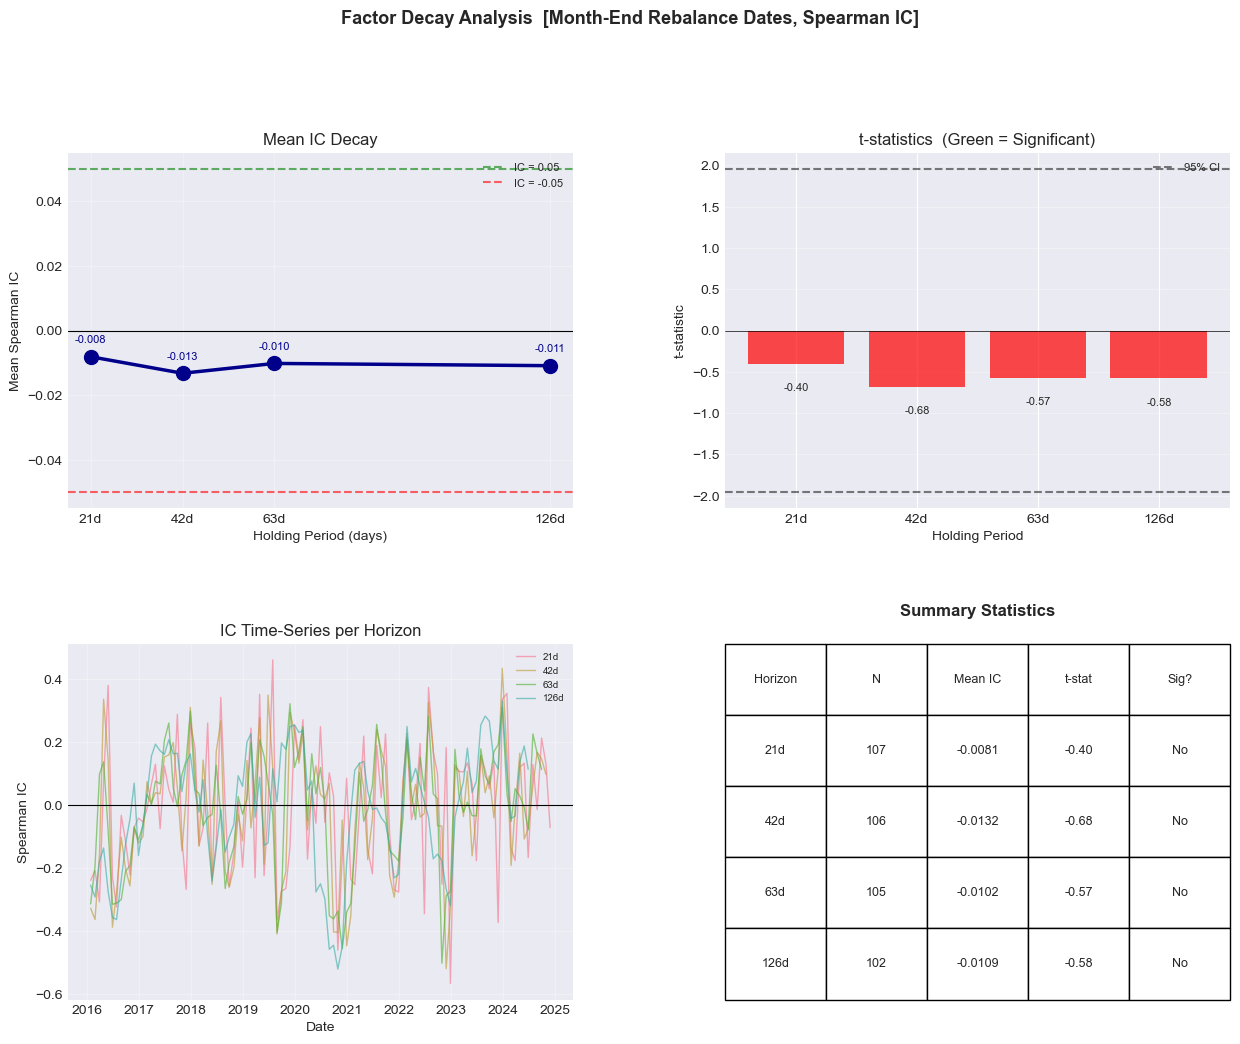

In [7]:
"""
Sensitivity and Decay Analysis for Momentum Strategy

Run this script from your project root directory:
    python notebooks/sensitivity_decay_analysis.py

Or copy the code cells into your existing notebook
"""

import sys
import os

project_root = os.path.abspath('..')

sys.path.insert(0, project_root)              # for config/
sys.path.insert(0, os.path.join(project_root, 'src'))  # for modules

# print(f"Project root: {project_root}")
# print(f"Src path: {sys.path[0]}")

from data_manager import DataManager
from factor_engine import MomentumFactor
from performance_analyzer import PerformanceAnalyzer
from config import *
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


print("✓ All modules imported")
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ──────────────────────────────────────────────────────────────────────────────
# HELPER: identify month-end trading days from a DatetimeIndex
# ──────────────────────────────────────────────────────────────────────────────

def get_month_end_dates(date_index: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """
    Return the last trading day of each calendar month
    present in `date_index`.
    """
    series = pd.Series(date_index, index=date_index)
    # resample to month-end, take the last actual date in each month
    month_ends = series.resample('BM').last().dropna()
    return pd.DatetimeIndex(month_ends.values)


# ──────────────────────────────────────────────────────────────────────────────
# MAIN FUNCTION  (drop-in replacement for run_decay_analysis)
# ──────────────────────────────────────────────────────────────────────────────

def run_decay_analysis_monthly(prices: pd.DataFrame,
                                momentum_factor: pd.DataFrame = None):
    """
    IC decay analysis sampled only on month-end rebalance dates.

    Parameters
    ----------
    prices : pd.DataFrame
        Adjusted close prices (dates × stocks).
    momentum_factor : pd.DataFrame, optional
        Pre-computed, normalised factor.  If None, 12-1 month momentum
        is calculated from `prices` using config constants.

    Returns
    -------
    ic_df : pd.DataFrame
        Summary table with Mean IC, Std IC, t-stat, p-value per horizon.
    """

    print("\n" + "="*80)
    print("DECAY ANALYSIS  [month-end sampling / Spearman IC]")
    print("="*80)

    # ── 1. Factor ──────────────────────────────────────────────────────────────
    if momentum_factor is None:
        print(f"\nCalculating {MOMENTUM_LOOKBACK}-{MOMENTUM_SKIP} momentum factor...")
        price_recent = prices.shift(MOMENTUM_SKIP)
        price_old    = prices.shift(MOMENTUM_LOOKBACK)
        raw_momentum = (price_recent / price_old) - 1
        # Cross-sectional z-score normalisation
        momentum = raw_momentum.sub(raw_momentum.mean(axis=1), axis=0) \
                               .div(raw_momentum.std(axis=1),  axis=0)
        print("✓ Factor calculated and normalised")
    else:
        momentum = momentum_factor
        print("✓ Using supplied factor")

    # ── 2. Horizons aligned to strategy ────────────────────────────────────────
    horizons       = [21, 42, 63, 126]
    horizon_labels = ['21d', '42d', '63d', '126d']

    # ── 3. Forward returns (full daily grid) ───────────────────────────────────
    print(f"\nCalculating forward returns for horizons: {horizon_labels}...")
    fwd_returns = {h: prices.shift(-h) / prices - 1 for h in horizons}
    print("✓ Forward returns calculated")

    # ── 4. Month-end rebalance dates ───────────────────────────────────────────
    rebal_dates = get_month_end_dates(prices.index)
    # Only keep dates where the factor already has valid data
    valid_factor_dates = momentum.dropna(how='all').index
    rebal_dates = rebal_dates[rebal_dates.isin(valid_factor_dates)]

    print(f"\nRebalance dates available for IC calculation: {len(rebal_dates)}")
    print(f"  First: {rebal_dates[0].date()}   Last: {rebal_dates[-1].date()}")

    # ── 5. IC calculation ──────────────────────────────────────────────────────
    print("\nCalculating Spearman IC on rebalance dates...")

    ic_results   = []
    ic_ts_all    = {}          # keep time-series for diagnostics

    for i, horizon in enumerate(horizons):
        ic_series   = []
        date_series = []

        for date in rebal_dates:
            # Forward return is only valid if date + horizon is within data
            if date not in fwd_returns[horizon].index:
                continue

            factor_cs  = momentum.loc[date].dropna()
            returns_cs = fwd_returns[horizon].loc[date].dropna()

            common = factor_cs.index.intersection(returns_cs.index)
            if len(common) < 20:
                continue

            # Spearman rank correlation (rank IC — more robust than Pearson)
            rho, _ = stats.spearmanr(factor_cs[common], returns_cs[common])

            if not np.isnan(rho):
                ic_series.append(rho)
                date_series.append(date)

        ic_ts_all[horizon] = pd.Series(ic_series, index=date_series)

        if len(ic_series) > 0:
            ic_mean = np.mean(ic_series)
            ic_std  = np.std(ic_series, ddof=1)
            n       = len(ic_series)
            t_stat  = ic_mean / (ic_std / np.sqrt(n)) if ic_std > 0 else 0
            p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n - 1)) if n > 1 else 1

            ic_results.append({
                'Horizon'    : horizon_labels[i],
                'Days'       : horizon,
                'N'          : n,
                'Mean IC'    : ic_mean,
                'Std IC'     : ic_std,
                'IC/Std'     : ic_mean / ic_std if ic_std > 0 else 0,
                't-stat'     : t_stat,
                'p-value'    : p_value,
                'Significant': 'Yes' if p_value < 0.05 else 'No',
            })

            sig_marker = "✓" if p_value < 0.05 else " "
            print(f"  {sig_marker} {horizon_labels[i]:5s}: "
                  f"IC = {ic_mean:+.4f}  "
                  f"(t = {t_stat:+.2f},  n = {n})")

    ic_df = pd.DataFrame(ic_results)

    print("\n" + "-"*80)
    print("INFORMATION COEFFICIENT DECAY  [month-end Spearman]")
    print("-"*80)
    print(ic_df[['Horizon', 'N', 'Mean IC', 'Std IC', 't-stat', 'Significant']]
          .to_string(index=False))

    # ── 6. Visualisation ───────────────────────────────────────────────────────
    fig = plt.figure(figsize=(15, 11))
    fig.suptitle('Factor Decay Analysis  [Month-End Rebalance Dates, Spearman IC]',
                 fontsize=13, fontweight='bold', y=1.01)

    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[1, 1])

    # (a) Mean IC decay
    ax0.plot(ic_df['Days'], ic_df['Mean IC'],
             marker='o', linewidth=2.5, markersize=10, color='darkblue')
    ax0.axhline(y=0,    color='black', linewidth=0.8)
    ax0.axhline(y=0.05, color='green', linestyle='--', alpha=0.6, label='IC = 0.05')
    ax0.axhline(y=-0.05, color='red', linestyle='--', alpha=0.6, label='IC = -0.05')
    for _, row in ic_df.iterrows():
        ax0.annotate(f"{row['Mean IC']:+.3f}",
                     xy=(row['Days'], row['Mean IC']),
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=8, color='darkblue')
    ax0.set_title('Mean IC Decay')
    ax0.set_xlabel('Holding Period (days)')
    ax0.set_ylabel('Mean Spearman IC')
    ax0.legend(fontsize=8)
    ax0.grid(True, alpha=0.3)
    ax0.set_xticks(ic_df['Days'])
    ax0.set_xticklabels(ic_df['Horizon'])

    # (b) t-statistics
    colors = ['green' if p < 0.05 else 'red' for p in ic_df['p-value']]
    bars = ax1.bar(ic_df['Horizon'], ic_df['t-stat'], color=colors, alpha=0.7)
    ax1.axhline(y= 1.96, color='black', linestyle='--', alpha=0.5, label='95% CI')
    ax1.axhline(y=-1.96, color='black', linestyle='--', alpha=0.5)
    ax1.axhline(y=0, color='black', linewidth=0.5)
    for bar, val in zip(bars, ic_df['t-stat']):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 val + (0.15 if val >= 0 else -0.35),
                 f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    ax1.set_title('t-statistics  (Green = Significant)')
    ax1.set_xlabel('Holding Period')
    ax1.set_ylabel('t-statistic')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3, axis='y')

    # (c) IC time-series for each horizon
    for horizon, label in zip(horizons, horizon_labels):
        ts = ic_ts_all[horizon]
        ax2.plot(ts.index, ts.values, alpha=0.6, linewidth=1, label=label)
    ax2.axhline(y=0, color='black', linewidth=0.8)
    ax2.set_title('IC Time-Series per Horizon')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Spearman IC')
    ax2.legend(fontsize=7)
    ax2.grid(True, alpha=0.3)

    # (d) Summary table
    ax3.axis('off')
    table_data = [
        [row['Horizon'],
         str(int(row['N'])),
         f"{row['Mean IC']:+.4f}",
         f"{row['t-stat']:+.2f}",
         row['Significant']]
        for _, row in ic_df.iterrows()
    ]
    table = ax3.table(
        cellText=table_data,
        colLabels=['Horizon', 'N', 'Mean IC', 't-stat', 'Sig?'],
        cellLoc='center', loc='center',
        bbox=[0, 0, 1, 1]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.2)
    ax3.set_title('Summary Statistics', fontweight='bold', pad=20)

    plt.savefig('decay_analysis_monthly.png', dpi=150, bbox_inches='tight')
    print("\n✓ Saved: decay_analysis_monthly.png")
    plt.show()

    return ic_df, ic_ts_all


# ──────────────────────────────────────────────────────────────────────────────
# ENTRY POINT
# ──────────────────────────────────────────────────────────────────────────────

if __name__ == '__main__':
    print("Loading prices...")
    prices = pd.read_csv(
        os.path.join(DATA_DIR, 'prices_adjusted.csv'),
        index_col=0, parse_dates=True
    )
    print(f"✓ {prices.shape[0]} days × {prices.shape[1]} stocks")
    print(f"  {prices.index[0].date()} → {prices.index[-1].date()}")

    ic_df, ic_ts = run_decay_analysis_monthly(prices)


Calculating Momentum Factor...
Lookback period: 126 days (6.0 months)
Skip period: 21 days (1.0 months)

Generating signals...
Number of quantiles: 5


INFO:factor_engine:Constructing Long-Short Portfolio | long_q=5 | short_q=1 | rebal=BM



Signal distribution (last date with data):
2025-01-24 00:00:00
1.0    93
2.0    93
3.0    92
4.0    93
5.0    93
Name: count, dtype: int64

Unique quantiles generated: [1.0, 2.0, 3.0, 4.0, 5.0]
All 5 quantiles successfully generated

Constructing Long-Short Portfolio...
Long: Quantile 5
Short: Quantile 1
Rebalancing: MONTHLY (end of month)

Total rebalancing dates: 105

Calculating Momentum Factor...
Lookback period: 189 days (9.0 months)
Skip period: 21 days (1.0 months)

Generating signals...
Number of quantiles: 5


INFO:factor_engine:Constructing Long-Short Portfolio | long_q=5 | short_q=1 | rebal=BM



Signal distribution (last date with data):
2025-01-24 00:00:00
1.0    93
2.0    93
3.0    92
4.0    93
5.0    93
Name: count, dtype: int64

Unique quantiles generated: [1.0, 2.0, 3.0, 4.0, 5.0]
All 5 quantiles successfully generated

Constructing Long-Short Portfolio...
Long: Quantile 5
Short: Quantile 1
Rebalancing: MONTHLY (end of month)

Total rebalancing dates: 102

Calculating Momentum Factor...
Lookback period: 252 days (12.0 months)
Skip period: 21 days (1.0 months)

Generating signals...
Number of quantiles: 5


INFO:factor_engine:Constructing Long-Short Portfolio | long_q=5 | short_q=1 | rebal=BM



Signal distribution (last date with data):
2025-01-24 00:00:00
1.0    93
2.0    93
3.0    92
4.0    93
5.0    93
Name: count, dtype: int64

Unique quantiles generated: [1.0, 2.0, 3.0, 4.0, 5.0]
All 5 quantiles successfully generated

Constructing Long-Short Portfolio...
Long: Quantile 5
Short: Quantile 1
Rebalancing: MONTHLY (end of month)

Total rebalancing dates: 99

Calculating Momentum Factor...
Lookback period: 315 days (15.0 months)
Skip period: 21 days (1.0 months)

Generating signals...
Number of quantiles: 5


INFO:factor_engine:Constructing Long-Short Portfolio | long_q=5 | short_q=1 | rebal=BM



Signal distribution (last date with data):
2025-01-24 00:00:00
1.0    93
2.0    93
3.0    92
4.0    93
5.0    93
Name: count, dtype: int64

Unique quantiles generated: [1.0, 2.0, 3.0, 4.0, 5.0]
All 5 quantiles successfully generated

Constructing Long-Short Portfolio...
Long: Quantile 5
Short: Quantile 1
Rebalancing: MONTHLY (end of month)

Total rebalancing dates: 96

Parameter Sensitivity Analysis:
   Lookback (months)    Return  Volatility    Sharpe
0                6.0  0.170895    0.207613  0.823142
1                9.0  0.166944    0.210002  0.794967
2               12.0  0.172563    0.208204  0.828818
3               15.0  0.169228    0.210013  0.805799


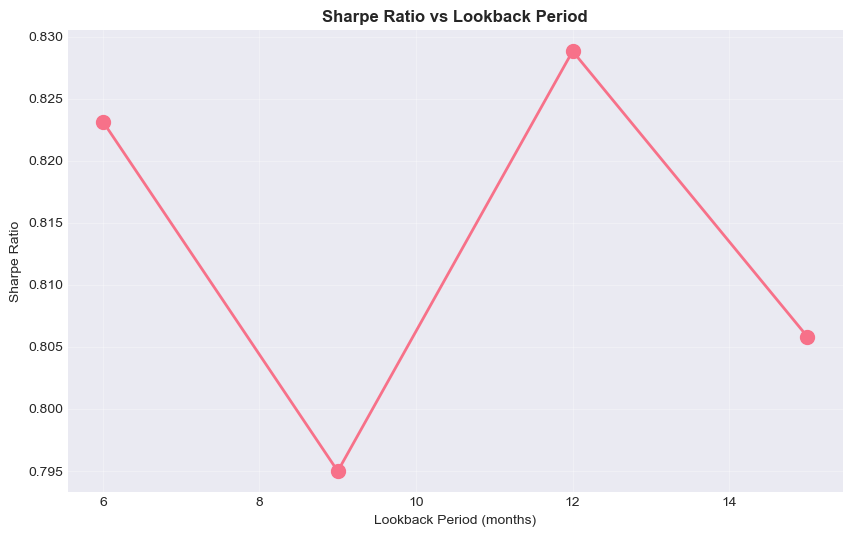

In [ ]:
# Test different lookback periods
lookback_periods = [126, 189, 252, 315]  # 6, 9, 12, 15 months

results = []

for lookback in lookback_periods:
    # Calculate momentum with different lookback
    momentum_engine = MomentumFactor(lookback=lookback, skip_period=21)
    factor = momentum_engine.calculate_momentum(prices)
    factor_norm = momentum_engine.normalize_factor(factor, method='z-score')
    sigs = momentum_engine.generate_signals(factor_norm)
    rets, _ = momentum_engine.create_long_short_portfolio(sigs, prices)
    
    # Calculate Sharpe
    ann_return = rets.mean() * 252
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol
    
    results.append({
        'Lookback (months)': lookback / 21,
        'Return': ann_return,
        'Volatility': ann_vol,
        'Sharpe': sharpe
    })

results_df = pd.DataFrame(results)
print("\nParameter Sensitivity Analysis:")
print(results_df)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results_df['Lookback (months)'], results_df['Sharpe'], 
        marker='o', linewidth=2, markersize=10)
ax.set_title('Sharpe Ratio vs Lookback Period', fontsize=12, fontweight='bold')
ax.set_xlabel('Lookback Period (months)')
ax.set_ylabel('Sharpe Ratio')
ax.grid(True, alpha=0.3)
plt.show()